## В данном ноутбуке выполним статистическую проверку различий между контрольной и тестовой группами.

Нам нужно:

- определить, является ли различие в коэффициенте конверсии статистически значимым;
- проверить, различаются ли группы по времени, проведённому на сайте;
- проверить, различаются ли группы по количеству просмотренных страниц.

Для анализа будем использованы следующие статистические методы:

- **критерий хи-квадрат Пирсона;**
- **критерий Манна-Уитни.**

Импортируем библиотеки

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency, mannwhitneyu

Загрузим датасет

In [2]:
df = pd.read_csv('../processed_files/ab_testing_processed.csv')
df.head()

,User ID,Group,Page Views,Time Spent,Conversion,Device,Location,Conversion_binary
0,14292,B,3,424,No,Mobile,Northern Ireland,0
1,11682,A,9,342,No,Mobile,Scotland,0
2,19825,A,2,396,No,Desktop,Northern Ireland,0
3,16080,B,4,318,No,Desktop,Wales,0
4,18851,A,1,338,Yes,Desktop,Scotland,1


Для оценки зависимости между принадлежностью пользователя к группе A/B и фактом совершения конверсии используем критерий хи-квадрат Пирсона.

Сформулируем гипотезы:

- H0: коэффициент конверсии не зависит от группы пользователя, то есть цвет фона сайта не влияет на конверсию.
- H1: коэффициент конверсии зависит от группы пользователя, то есть цвет фона сайта влияет на конверсию.

In [3]:
conversion_table = pd.crosstab(df['Group'], df['Conversion'])
conversion_table

Conversion,No,Yes
Group,,
A,2383,136
B,2132,349


In [4]:
chi2, p_value, dof, expected = chi2_contingency(conversion_table)

print(f'Статистика хи-квадрат: {chi2:.4f}')
print(f'p-value: {p_value:.30f}')
print(f'Число степеней свободы: {dof}')

Статистика хи-квадрат: 106.2281
p-value: 0.000000000000000000000000657174
Число степеней свободы: 1


## Интерпретация результата критерия хи-квадрат

Полученное значение p-value значительно меньше a = 0.05.
Значит, нулевая гипотеза отвергается.
Между принадлежностью пользователя к группе A/B и фактом совершения конверсии существует статистически значимая связь.
То есть, изменение цвета фона оказывает влияние на вероятность совершения целевого действия пользователем.

In [5]:
expected_df = pd.DataFrame(
    expected,
    index = conversion_table.index,
    columns = conversion_table.columns
)
expected_df

Conversion,No,Yes
Group,,
A,2274.657,244.343
B,2240.343,240.657


Ожидаемые частоты показывают, каким было бы распределение конверсий в группах A и B при отсутствии связи между принадлежностью пользователя к группе и фактом совершения конверсии.

In [6]:
n = conversion_table.sum().sum()
cramers_v = np.sqrt(chi2 / n)
print(f"Cramer's V: {cramers_v:.4f}")

Cramer's V: 0.1458


Коэффициент Cramer's V = 0.145, что указывает на наличие статистически значимой, но слабой связи между принадлежностью пользователя к группе и фактом совершения конверсии.

Проверим различие по времени на сайте с помощью статистики Манна-Уитни. Не будем использовать t-test, так как не обязательно наши данные имеют нормальное распределение и не имеют сильных выбросов.
Гипотезы:
- H0: Распределение Time Spent одинаково в группах A и B.
- H1: Распределения различаются.

In [7]:
group_a_time = df[df['Group'] == 'A']['Time Spent']
group_b_time = df[df['Group'] == 'B']['Time Spent']
stat_time, p_time = mannwhitneyu(group_a_time, group_b_time, alternative = 'two-sided')

print(f'Статистика Манна-Уитни: {stat_time:.2f}')
print(f'p-value: {p_time:.4f}')

Статистика Манна-Уитни: 3101095.00
p-value: 0.6420


p-value > 0.05, значит нулевую гипотезу не отвергаем, значит статистически значимого различия по времени на сайте между группами A и B нет.
Цвет фона влияет на конверсию, но не влияет на длительность пребывания на сайте.

Построим boxplot по времени, проведенном на сайте.

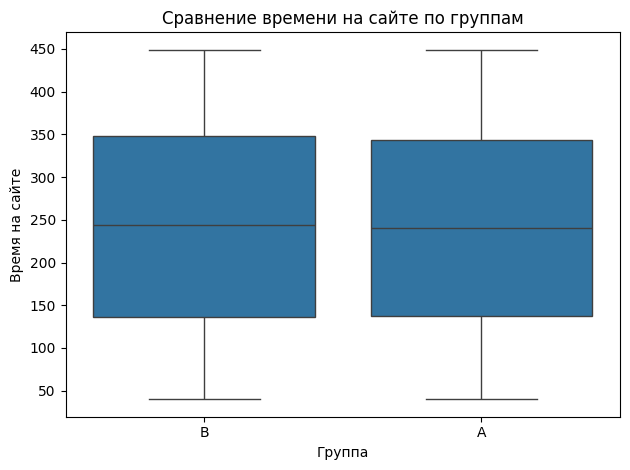

In [8]:
sns.boxplot(data = df, x = 'Group', y = 'Time Spent')
plt.title('Сравнение времени на сайте по группам')
plt.xlabel('Группа')
plt.ylabel('Время на сайте')
plt.tight_layout()
plt.show()

В группах A и B медианы почти одинаковые, значит центральные значения времени на сайте в группах практически совпадают.
Судя по размеру коробки (размах между 25 и 75 процентилем) разброс значений в группах очень похож.
Судя по верхним и нижним "усам" групп A и B верхние и нижние границы распределения очень близки.
Имея такие графики распределения времени на сайте и значение p-value = 0.642, можем сказать, что распределения похожи и статистически различий нет.

Проверим, различаются ли группы A и B по количеству просмотренных страниц.
Для этого также используем критерий Манна–Уитни, так как признак Page Views является количественным, а сравнение проводится между двумя независимыми выборками.
Гипотезы:
- H0: распределение количества просмотренных страниц одинаково в группах A и B.
- H1: распределение количества просмотренных страниц различается.

In [9]:
group_a_views = df[df['Group'] == 'A']['Page Views']
group_b_views = df[df['Group'] == 'B']['Page Views']
stat_views, p_views = mannwhitneyu(group_a_views, group_b_views, alternative = 'two-sided')
print(f'Статистика Манна-Уитни: {stat_views:.2f}')
print(f'p-value: {p_views:.4f}')

Статистика Манна-Уитни: 3165458.00
p-value: 0.4247


Значение p-value превышает уровень значимости 0.05, значит нет оснований отвергать нулевую гипотезу.
Статистически значимого различия по количеству просмотренных страниц между группами A и B нет.

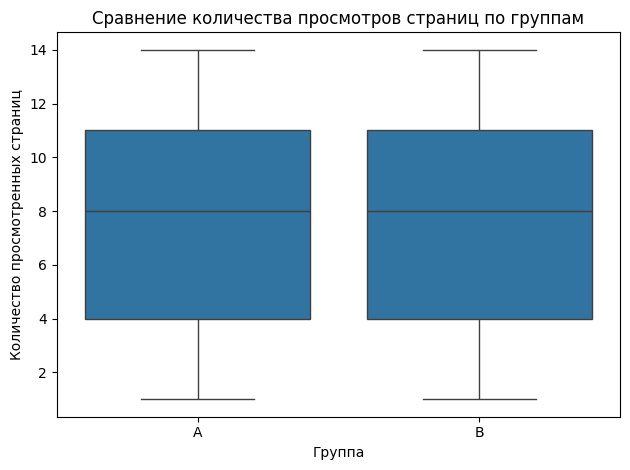

In [10]:
sns.boxplot(data = df, x = 'Group', y = 'Page Views', order = ['A', 'B'])
plt.title('Сравнение количества просмотров страниц по группам')
plt.xlabel('Группа')
plt.ylabel('Количество просмотренных страниц')
plt.tight_layout()
plt.show()

Boxplot показывает, что распределение количества просмотренных страниц в группах A и B практически совпадает.
Медианные значения находятся на одинаковом уровне, интерквартильный размах и общий диапазон значений также похоже.
Это визуально подтверждает отсутствие выраженного различия между группами и совпадает с результатом критерия Манна–Уитни.

## Покажем сводную таблицу результатов статистических тестов

In [11]:
pivot_table = pd.DataFrame({
    'Метрика': ['Conversion', 'Time Spent', 'Page Views'],
    'Тест': ['Хи-квадрат', 'Манна-Уитни', 'Манна-Уитни'],
    'p-value': [p_value, p_time, p_views]
})
pivot_table['p-value'] = pivot_table['p-value'].round(8)
pivot_table['Результат'] = pivot_table['p-value'].apply(
    lambda x: 'Значимо' if x < 0.05 else 'Не значимо'
)
pivot_table

,Метрика,Тест,p-value,Результат
0,Conversion,Хи-квадрат,0.000000,Значимо
1,Time Spent,Манна-Уитни,0.642030,Не значимо
2,Page Views,Манна-Уитни,0.424678,Не значимо


# Выводы по статистическим тестам

Сравнение групп A и B показало, что изменение цвета фона сайта оказывает статистически значимое влияние на коэффициент конверсии пользователей.
При этом различия по времени, проведённому на сайте, и количеству просмотренных страниц статистически значимыми не являются.
Таким образом, изменение интерфейса влияет на вероятность совершения целевого действия, не сопровождаясь выраженным изменением общей пользовательской активности.